# 38. Comparing the two toy-generation methods

**Objectives:**
- Generate a toy from the same model with `method="inverse-transform"` (the default) and with
  `method="accept-reject"`.
- Overlay their `s12`/`s13` histograms to show statistical agreement between the two samplers.
- Understand what each method actually does under the hood.

Run cells top to bottom in a fresh kernel. Masses are in GeV, invariants in GeV², daughter
indices start at zero.


In [1]:
from dalitzplotfitter import enable_x64
enable_x64()  # Must precede numerical work: amplitudes use complex128.

import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from dalitzplotfitter import (
    DecayChannel, DecayModel, NonResonant, RealImag, Resonance, generate_toy,
)


## 1. Build one small illustrative model

Per `docs/toy_generation.md`, `inverse-transform` and `accept-reject` are exactly two
independent public samplers: `inverse-transform` tabulates the Dalitz-plane CDFs and inverts them
(a numerical Rosenblatt transform), while `accept-reject` is a Laura++-style envelope/restart
rejection algorithm. As CLAUDE.md notes, the two are *validated against each other*, not derived
from one another — agreement between them is evidence, not a proof that one implements the other.


In [2]:
channel = DecayChannel("D+", ("pi-", "pi+", "pi+"))
components = [
    Resonance("rho", (0, 1), RealImag(1, 0), mass=0.7753, width=0.1491, spin=1),
    NonResonant(RealImag(0.5, -0.2), name="NR"),
]
model = DecayModel(
    channel, components, normalization_method="square-dalitz",
    normalization_resolution=100, normalization_pair=(0, 1),
)
truth = {p.name: p.value for p in model.parameters}
print("Model components:", [c.name for c in model.components])


Model components: ['rho', 'NR']


## 2. Generate one toy with each method

Both calls request the same number of events and a fixed `seed`; the two samplers use unrelated
random-number streams, so equal seeds do not produce identical events, only comparable statistics.


In [3]:
n_events = 6000

toy_inverse = generate_toy(
    model, n_events, parameters=truth, seed=11,
    method="inverse-transform", inverse_resolution=512, include_momenta=False,
)
toy_accept = generate_toy(
    model, n_events, parameters=truth, seed=11,
    method="accept-reject", include_momenta=False,
)
print(f"inverse-transform: {toy_inverse.size} events, accept-reject: {toy_accept.size} events")


inverse-transform: 6000 events, accept-reject: 6000 events


## 3. Overlay the s12 and s13 projections

Both histograms are normalized to unit area (`density=True`) so the two methods can be compared
directly regardless of the exact accepted count.


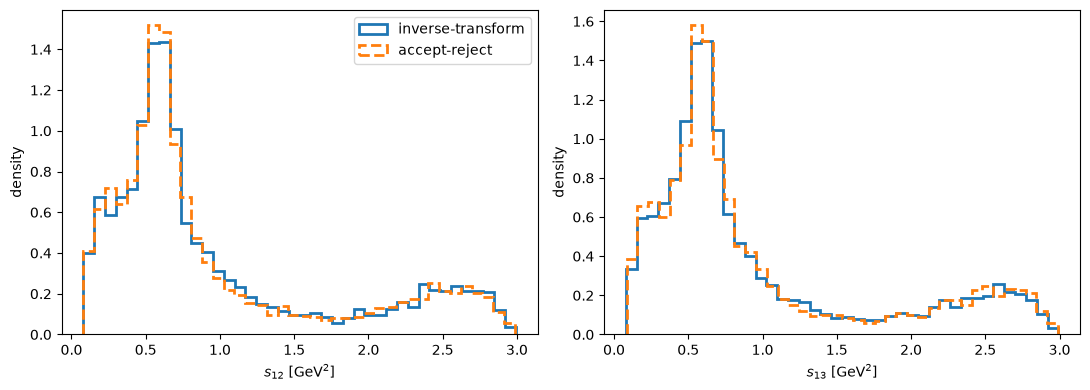

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
bins = 40
for label, toy, style in (
    ("inverse-transform", toy_inverse, dict(histtype="step", linewidth=2)),
    ("accept-reject", toy_accept, dict(histtype="step", linewidth=2, linestyle="--")),
):
    axes[0].hist(np.asarray(toy.s12), bins=bins, density=True, label=label, **style)
    axes[1].hist(np.asarray(toy.s13), bins=bins, density=True, label=label, **style)
axes[0].set(xlabel=r"$s_{12}$ [GeV$^2$]", ylabel="density")
axes[1].set(xlabel=r"$s_{13}$ [GeV$^2$]", ylabel="density")
axes[0].legend()
fig.tight_layout()
plt.show()


## 4. A simple numerical agreement check

A binned chi-square-like comparison of the two normalized histograms is enough for this lesson;
`tutorial_09_goodness_of_fit.ipynb` covers proper goodness-of-fit machinery
(`BinnedChi2Result`, `point_to_point_dissimilarity`) for a rigorous comparison.


In [5]:
edges = np.histogram_bin_edges(np.asarray(toy_inverse.s12), bins=25)
hist_inverse, _ = np.histogram(np.asarray(toy_inverse.s12), bins=edges, density=True)
hist_accept, _ = np.histogram(np.asarray(toy_accept.s12), bins=edges, density=True)
max_abs_diff = float(np.max(np.abs(hist_inverse - hist_accept)))
print(f"Max |density difference| across s12 bins: {max_abs_diff:.4f}")
assert max_abs_diff < 0.5, "inverse-transform and accept-reject disagree beyond expected statistical spread"
print("The two independent samplers agree within statistical fluctuations.")


Max |density difference| across s12 bins: 0.0429
The two independent samplers agree within statistical fluctuations.


## Summary and exercises

1. `inverse-transform` (default) tabulates Dalitz-plane CDFs on a grid and inverts them
   numerically; accuracy is controlled by `inverse_resolution`/`inverse_quantile_resolution`.
2. `accept-reject` restarts with an enlarged envelope whenever a proposal exceeds it (the
   Laura++ safety principle) and never clips probabilities.
3. Increase `n_events` and/or `inverse_resolution` and see the two histograms converge further.
4. For repeated generation at fixed parameters, `prepare_inverse_toy_generator` amortizes the
   inverse-transform preparation cost — see the next lesson.

Reference: [toy generation](../../docs/toy_generation.md).

Return to [the course guide](TUTORIALS.md).
